In [1]:
import argparse, os, sys, datetime, glob, importlib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
from torchvision.utils import save_image
from torchvision.io.image import read_image
from torchvision import transforms

sys.path.append(os.getcwd())
sys.path.insert(0, "../")
os.chdir("../")
print(f"Current work path: {os.getcwd()}")

from taming.mask_utils.mask_model import Mask_Model_4step

/home/xnf/ls/envs/compressai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current work path: /mnt/data/xnf/ImageGeneration/vqgan_4step


Using /home/xnf/.cache/torch_extensions/py38_cu117 as PyTorch extensions root...
Emitting ninja build file /home/xnf/.cache/torch_extensions/py38_cu117/torchac_backend/build.ninja...
Building extension module torchac_backend...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)
Loading extension module torchac_backend...


ninja: no work to do.


In [2]:
DEVICE = "cuda:0"
mask_model = Mask_Model_4step(mask_type='edge').eval().to(device=DEVICE)

Download finished


In [3]:
from PIL import Image
image_path = "/mnt/Xnf/DataSets/CLIC/professional_test_2020/3a5f16e4c64fe70f8481e184574867e2.png"
image = read_image(image_path).float() / 255.0
image = image.unsqueeze(0).to(device=DEVICE)
B, C, H, W = image.shape

libpng warning: iCCP: known incorrect sRGB profile


In [4]:
dummy_indices = torch.ones([B, H // 16, W // 16], dtype=torch.int32, device=DEVICE)
mask, info_dict = mask_model(image, dummy_indices)

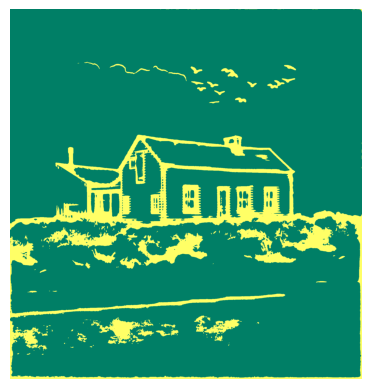

In [5]:
edge_full_size = info_dict['edge_info']['edge'] >= torch.mean(info_dict['edge_info']['edge'])
edge_full_size = edge_full_size.float().cpu().squeeze(0).numpy()
plt.imshow(edge_full_size, cmap='summer')
plt.axis('off')
plt.savefig('edge.png', bbox_inches='tight',pad_inches = 0)
plt.show()
plt.close()

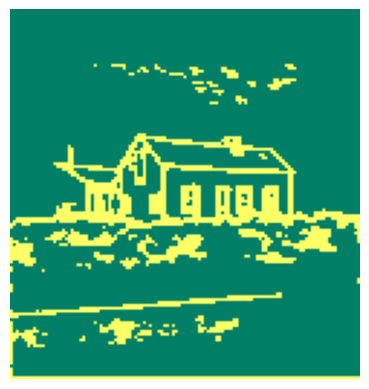

In [6]:
edge_down = info_dict['edge_info']['edge_down'] >= torch.mean(info_dict['edge_info']['edge_down'])
edge_down = edge_down.float().cpu().squeeze(0).numpy()
plt.imshow(edge_down, cmap='summer')
plt.axis('off')
plt.savefig('edge_down.png', bbox_inches='tight',pad_inches = 0)
plt.show()
plt.close()

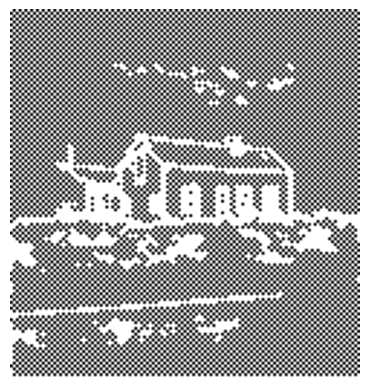

In [7]:
mask = mask.float().cpu().squeeze(0).numpy()
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.savefig('mask_down.png', bbox_inches='tight',pad_inches = 0)
plt.show()
plt.close()